In [36]:
import os
from pathlib import Path
import torch
import kagglehub
from torchvision import datasets, transforms
import shutil
from matplotlib import pyplot as plt
import numpy as np
import collections
from sklearn.model_selection import train_test_split
import random
from torch.utils.data import Subset, DataLoader
from collections import defaultdict
import torch.nn as nn
import torch.nn.functional as F
import time
import copy
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd


In [5]:
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('plant-seedlings-classification')

100%|██████████| 1.69G/1.69G [00:51<00:00, 35.2MB/s]

Extracting files...


# **ImageNet Normalization (Mean/Std)**

- Pretrained CNNs not only expect 224×224 input, but also **specific pixel statistics**:  
  - **Mean:** `[0.485, 0.456, 0.406]`  
  - **Standard Deviation:** `[0.229, 0.224, 0.225]`
- These values are computed from the **entire ImageNet dataset** and represent the typical RGB distribution across millions of natural images.

**Why normalize?**
- Ensures input images are **centered** (mean 0) and **scaled** (std ~1).
- Matches the distribution that pretrained weights were optimized on — crucial for transfer learning to work well.
- Without this, the pretrained features would misinterpret brightness/contrast and hurt performance.

In [6]:
!ls /root/.cache/kagglehub/competitions/

plant-seedlings-classification	plant-seedlings-classification.complete


In [7]:
!ls /root/.cache/kagglehub/competitions/plant-seedlings-classification

sample_submission.csv  test  train


In [8]:
!ls /root/.cache/kagglehub/competitions/plant-seedlings-classification/train

 Black-grass	    'Common wheat'	'Scentless Mayweed'
 Charlock	    'Fat Hen'		'Shepherds Purse'
 Cleavers	    'Loose Silky-bent'	'Small-flowered Cranesbill'
'Common Chickweed'   Maize		'Sugar beet'


In [9]:
!ls /root/.cache/kagglehub/competitions/plant-seedlings-classification/test

0021e90e4.png  33748968f.png  65e97117e.png  98d819587.png  cb496f36e.png
003d61042.png  338c7e907.png  664194d19.png  98da6ef4e.png  cb76a7766.png
007b3da8b.png  34dd57ca9.png  6680836dd.png  99036c51d.png  cbba27d89.png
0086a6340.png  3526b05cc.png  668c1007c.png  99569b224.png  cbe761896.png
00c47e980.png  35a90f8d0.png  66ab0e8d0.png  995c7ab1e.png  cc3d2a59a.png
00d090cde.png  35cf9fa01.png  675ec1b0b.png  9a3f20121.png  cc74feadc.png
00ef713a8.png  35ebe165c.png  67ce3eaa6.png  9aa5587fe.png  cd5f0db1c.png
01291174f.png  36839d5e9.png  67e185673.png  9b4800b42.png  cd6adba97.png
026716f9b.png  36d62bf36.png  686dc7ec8.png  9b9911f20.png  ce15eee52.png
02cfeb38d.png  36ed4f215.png  6908fb540.png  9baf94467.png  ce3d280eb.png
03566743d.png  37297a64c.png  6982a9d30.png  9c0c5b731.png  ce42adffb.png
03a2ee656.png  37714071b.png  699d3c707.png  9c32a797e.png  cec5bf198.png
03e322a29.png  377283a21.png  69d1669f8.png  9c777333d.png  cf3a8b2fd.png
03ef36742.png  37c3108d6.png  6a41bf95

In [10]:
data_path = "/root/.cache/kagglehub/competitions/plant-seedlings-classification"
original_test_dir = os.path.join(data_path, "test")
new_parent_dir = os.path.join(data_path, "test_dir")

os.makedirs(new_parent_dir, exist_ok=True)

if os.path.exists(original_test_dir):
    shutil.move(original_test_dir, new_parent_dir)

In [11]:
data_path = "/root/.cache/kagglehub/competitions/plant-seedlings-classification"

test_data_path = os.path.join(data_path, "test_dir")
train_dir = os.path.join(data_path, "train")

# -----------------------------
#  Transformations
# -----------------------------
IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# -----------------------------
#  Load datasets
# -----------------------------
train_dataset = datasets.ImageFolder(train_dir, transform=transform)

test_dataset  = datasets.ImageFolder(test_data_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# -----------------------------
#  Verify
# -----------------------------
print(f"Train Classes: {train_dataset.classes}")
print(f"Test Classes found: {test_dataset.classes}")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
Test Classes found: ['test']
Train samples: 4750 | Test samples: 794


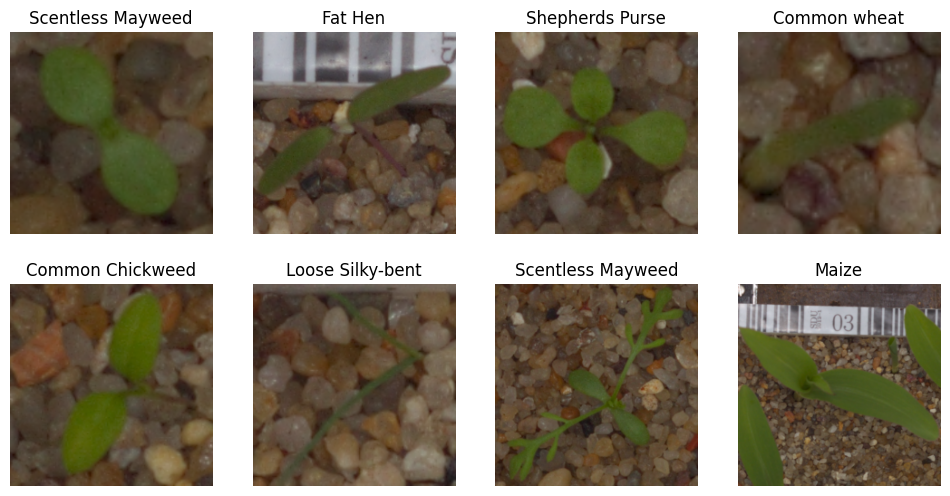

In [12]:
def imshow(inp, title=None):
    """Display a tensor image after unnormalizing (ImageNet stats)."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean  # unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Show first 8 training images
images, labels = next(iter(train_loader))
fig = plt.figure(figsize=(12, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    imshow(images[i], title=train_dataset.classes[labels[i]])
plt.show()

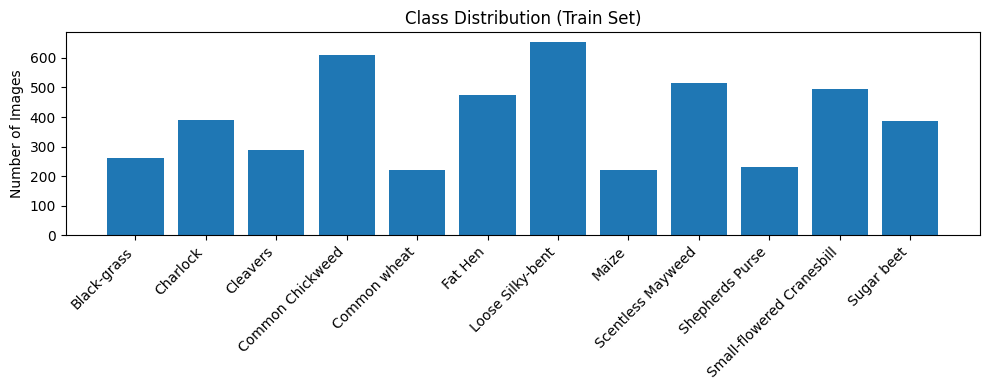

In [13]:
class_counts = collections.Counter([label for _, label in train_dataset.samples])

# Convert to list aligned with class_names
counts = [class_counts[i] for i in range(len(train_dataset.classes))]

# Plot
plt.figure(figsize=(10, 4))
plt.bar(train_dataset.classes, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (Train Set)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [14]:
CT_train_loader_bs20 = DataLoader(train_dataset, batch_size=32, shuffle=True)
CT_test_loader_bs50  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

CT_tr20_images, CT_tr20_labels = next(iter(CT_train_loader_bs20))
CT_te50_images, CT_te50_labels = next(iter(CT_test_loader_bs50))

CT_train_bs20_shape = CT_tr20_images.shape
CT_test_bs50_shape  = CT_te50_images.shape

print("CT_train_bs20_shape:", CT_train_bs20_shape)
print("CT_test_bs50_shape:",  CT_test_bs50_shape)

CT_train_bs20_shape: torch.Size([32, 3, 224, 224])
CT_test_bs50_shape: torch.Size([32, 3, 224, 224])


A **Convolutional Neural Network (CNN)** transforms raw image pixels into class probabilities through a structured hierarchy:

1. **Convolution Layers**  
   - Apply filters (kernels) to detect **local features** (edges, corners).  
2. **Pooling Layers**  
   - Downsample feature maps to reduce spatial size and enforce **translation invariance**.  
3. **Flatten**  
   - Convert 2D feature maps into a 1D vector for dense layers.  
4. **Fully Connected Layers (FC)**  
   - Combine features for **class-level reasoning**.  
5. **Softmax**  
   - Produce probabilities across all classes.

**Baseline CNN (Project 5)**

Here’s a schematic of the **2-conv + 2-FC** model we built for pet breed classification:

```text
Input (3 × 128 × 128)
        │
[Conv2D 3→16, 3×3] → ReLU → MaxPool(2×2)
        │
[Conv2D 16→32, 3×3] → ReLU → MaxPool(2×2)
        │
Flatten (32 × 32 × 32)
        │
[FC: 32×32×32 → 128] → ReLU
        │
[FC: 128 → 37] → Softmax

```


In [15]:
val_dir   = os.path.join(data_path, "val")

os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # All images in this class
    images = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Skip if validation already exists for this class
    val_class_path = os.path.join(val_dir, class_name)
    if not os.path.exists(val_class_path):
        os.makedirs(val_class_path, exist_ok=True)

    # 15% split for validation
    train_imgs, val_imgs = train_test_split(images, test_size=0.15, random_state=42)

    # Move validation images
    for img in val_imgs:
        dest_path = os.path.join(val_class_path, os.path.basename(img))
        shutil.move(img, dest_path)

print(f"Validation split created at: {val_dir}")

Validation split created at: /root/.cache/kagglehub/competitions/plant-seedlings-classification/val


In [16]:
IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Paths for train, val, test
test_dir = os.path.join(data_path, "test")

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_data_path, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")


Train samples: 4030
Val samples: 720
Test samples: 794
Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']


In [17]:
# -----------------------------
# Create 33% stratified subset
# -----------------------------
# Group indices by class
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(train_dataset):
    class_indices[label].append(idx)

# Sample 33% from each class
subset_indices = []
for class_label, indices in class_indices.items():
    n_samples = len(indices) // 3  # 33% of each class
    sampled_indices = random.sample(indices, n_samples)
    subset_indices.extend(sampled_indices)

# Create subset
train_dataset = Subset(train_dataset, subset_indices)

# -----------------------------
# 4. DataLoaders
# -----------------------------
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 5. Verify
# -----------------------------
print(f"Classes: {train_dataset.dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
Train: 1341 | Val: 720 | Test: 794


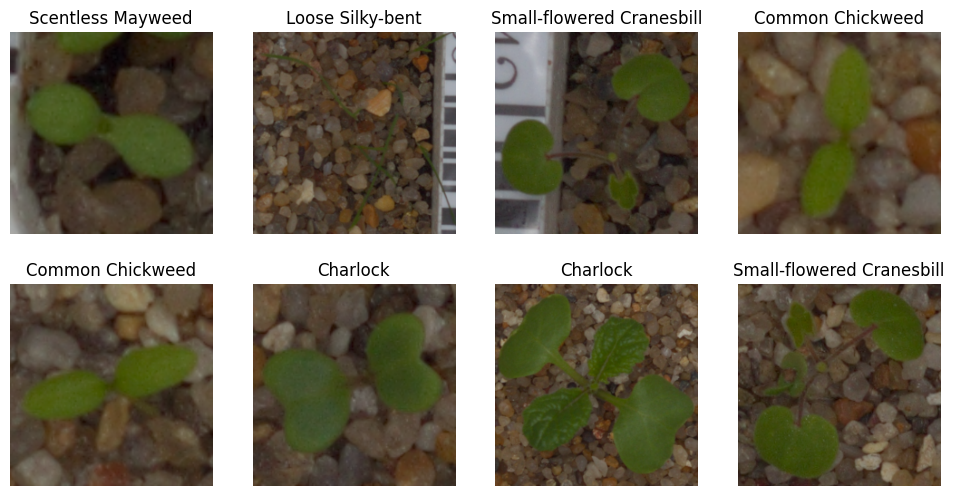

In [18]:
def imshow(inp, title=None):
    """Display a tensor image after unnormalizing (ImageNet stats)."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean  # unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

# Show first 8 images from train set
images, labels = next(iter(train_loader))
fig = plt.figure(figsize=(12, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    imshow(images[i], title=train_dataset.dataset.classes[labels[i]])
plt.show()


In [19]:
# Count per-class in the original full train (ImageFolder behind the Subset)
CT_orig_class_counts = collections.Counter()
for path, lbl in train_dataset.dataset.samples:
    cls_name = train_dataset.dataset.classes[lbl]
    CT_orig_class_counts[cls_name] += 1

# Count per-class in the subset using train_dataset.indices
CT_subset_class_counts = collections.Counter()
for idx in train_dataset.indices:
    lbl = train_dataset.dataset.samples[idx][1]
    cls_name = train_dataset.dataset.classes[lbl]
    CT_subset_class_counts[cls_name] += 1

# Compute per-class ratios
CT_subset_ratios = {cls: CT_subset_class_counts[cls] / CT_orig_class_counts[cls]
                    for cls in train_dataset.dataset.classes}

CT_ratio_min = min(CT_subset_ratios.values())
CT_ratio_max = max(CT_subset_ratios.values())

print("CT_subset_class_counts:", dict(CT_subset_class_counts))
print("CT_orig_class_counts:",   dict(CT_orig_class_counts))
print("CT_ratio_min/max:", CT_ratio_min, CT_ratio_max)


CT_subset_class_counts: {'Black-grass': 74, 'Charlock': 110, 'Cleavers': 81, 'Common Chickweed': 173, 'Common wheat': 62, 'Fat Hen': 134, 'Loose Silky-bent': 185, 'Maize': 62, 'Scentless Mayweed': 146, 'Shepherds Purse': 65, 'Small-flowered Cranesbill': 140, 'Sugar beet': 109}
CT_orig_class_counts: {'Black-grass': 223, 'Charlock': 331, 'Cleavers': 243, 'Common Chickweed': 519, 'Common wheat': 187, 'Fat Hen': 403, 'Loose Silky-bent': 555, 'Maize': 187, 'Scentless Mayweed': 438, 'Shepherds Purse': 196, 'Small-flowered Cranesbill': 421, 'Sugar beet': 327}
CT_ratio_min/max: 0.3315508021390374 0.3333333333333333


# **Custom CNN Architecture (LeNet-Style)**


**Design Inspiration: LeNet**

- **LeNet-5** (1998) was one of the first CNNs for image recognition.
- Architecture pattern:
  1. Convolution → Activation (ReLU)
  2. Pooling (downsample)
  3. Repeat for deeper features
  4. Flatten → Fully connected layers
  5. Output (softmax over classes)

**Proposed Architecture for Seedlings**

Input: **3×224×224 RGB images**

1. **Conv1 (3→32)**  
   - 3×3 kernel, padding=1 → preserves spatial size (224×224).  
   - Followed by ReLU + 2×2 MaxPooling → reduces to 32×112×112.

2. **Conv2 (32→64)**  
   - 3×3 kernel, padding=1 → 64×112×112.  
   - ReLU + 2×2 MaxPooling → 64×56×56.

3. **Conv3 (64→128)**  
   - 3×3 kernel, padding=1 → 128×56×56.  
   - ReLU + 2×2 MaxPooling → 128×28×28.

4. **Fully Connected (FC) Layers**  
   - Flatten 128×28×28 → 100,352 features.
   - FC1: 100,352 → 256  
   - FC2: 256 → 12 (number of plant classes)

**ASCII Diagram**

```text

Input (3×224×224)
        ↓ Conv1 + ReLU + Pool
  (32×112×112)
        ↓ Conv2 + ReLU + Pool
   (64×56×56)
        ↓ Conv3 + ReLU + Pool
   (128×28×28)
        ↓ Flatten
   (100,352)
        ↓ FC1 + ReLU
      (256)
        ↓ FC2 (Logits)
   (12 classes)
```

In [20]:
# -----------------------------
# Custom CNN (LeNet-style)
# -----------------------------
class SeedlingsCNN(nn.Module):
    def __init__(self, num_classes=12):
        super(SeedlingsCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 3 -> 32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 -> 64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64 -> 128
        self.pool = nn.MaxPool2d(2, 2)  # Downsampling (H,W halved each time)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 28 * 28, 256)  # Flatten after 3 pools
        self.fc2 = nn.Linear(256, num_classes)    # Output logits

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 3 -> 32, 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))  # 32 -> 64, 112 -> 56
        x = self.pool(F.relu(self.conv3(x)))  # 64 -> 128, 56 -> 28
        x = x.view(-1, 128 * 28 * 28)         # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                       # Raw logits
        return x

# Instantiate and print summary-like info
model = SeedlingsCNN(num_classes=12)
print(model)

# Parameter count
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total trainable parameters: {count_params(model):,}")

SeedlingsCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=12, bias=True)
)
Total trainable parameters: 25,786,700


# **Training Setup**


Now that we have defined our **custom CNN architecture**, we need to set up:
1. **Loss function** (how we measure prediction error)  
2. **Optimizer** (how we update weights)  
3. **Training loop** (forward → loss → backward → update)  


**Loss Function: CrossEntropyLoss**

- Suitable for **multi-class classification** (12 plant species).  
- Combines **LogSoftmax + Negative Log-Likelihood (NLLLoss)** internally.  
- Does not require us to apply softmax manually in the forward pass.

**Optimizer: Adam**

- Adaptive learning rate → works well out-of-the-box.  
- Faster convergence on small datasets compared to SGD.

**Training Strategy**

- **Epochs:** 5 (baseline; may adjust for performance)  
- **Batch size:** 32 (already set in loaders)  
- **Device:** CPU-only (per project lead requirement)  
- **Validation:** Evaluate after each epoch (using 15% val split)  

**Expected Outcome**

- Monitor **training vs validation loss/accuracy**  
- Detect **overfitting** (validation curve diverges)  
- Save **best weights** (lowest validation loss) for later evaluation

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=5, device=device):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    model.to(device)

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0.0
            running_corrects = 0
            total_samples = 0

            for batch_idx, (inputs, labels) in enumerate(tqdm(loader, desc=f'{phase.capitalize()}', leave=False)):
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Accumulate stats
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (outputs.argmax(1) == labels).sum().item()
                total_samples += labels.size(0)

            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects / total_samples

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc)
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc)

                # Save best model
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best val loss: {best_loss:.4f}")

    # Load best weights
    model.load_state_dict(best_model_wts)

    return model, (train_losses, val_losses, train_accuracies, val_accuracies)


In [23]:
model, history = train_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=10,
    device=device
)

Epoch 1/10
--------------------


Train Loss: 2.4905 Acc: 0.1365


Val Loss: 2.4453 Acc: 0.1569
Epoch 2/10
--------------------


Train Loss: 2.3933 Acc: 0.1641


Val Loss: 2.2195 Acc: 0.2111
Epoch 3/10
--------------------


...

Val Loss: 1.8225 Acc: 0.6111
Epoch 9/10
--------------------


Train Loss: 0.1197 Acc: 0.9612


Val Loss: 1.8796 Acc: 0.5944
Epoch 10/10
--------------------


Train Loss: 0.0290 Acc: 0.9918


Val Loss: 1.9806 Acc: 0.6319
Training complete in 5m 41s
Best val loss: 1.1935


In [24]:
torch.save(model.state_dict(), "seedlings_custom_cnn.pth")

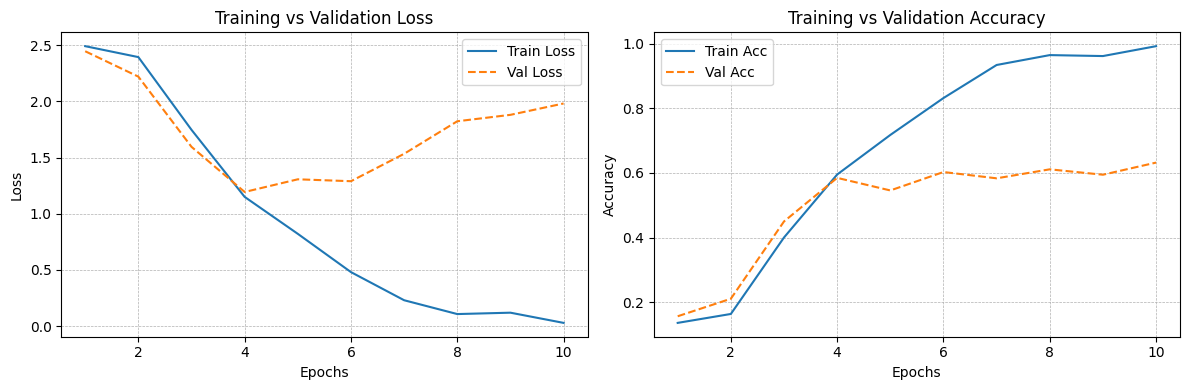

In [25]:
train_losses, val_losses, train_acc, val_acc = history

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()

plt.savefig('training_curves_student.png', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

In [28]:
model = SeedlingsCNN()
model.load_state_dict(torch.load("seedlings_custom_cnn.pth", map_location='cpu'))
model.eval()

SeedlingsCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=12, bias=True)
)

In [31]:
def evaluate_model(model, loader, device='cpu'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

Overall Validation Accuracy: 58.47%

Classification Report:
                           precision    recall  f1-score   support

              Black-grass       0.18      0.05      0.08        40
                 Charlock       0.66      0.73      0.69        59
                 Cleavers       0.65      0.80      0.71        44
         Common Chickweed       0.73      0.78      0.75        92
             Common wheat       0.40      0.06      0.10        34
                  Fat Hen       0.67      0.14      0.23        72
         Loose Silky-bent       0.60      0.88      0.71        99
                    Maize       0.77      0.29      0.43        34
        Scentless Mayweed       0.54      0.65      0.59        78
          Shepherds Purse       0.56      0.14      0.23        35
Small-flowered Cranesbill       0.85      0.75      0.79        75
               Sugar beet       0.34      0.83      0.48        58

                 accuracy                           0.58       720


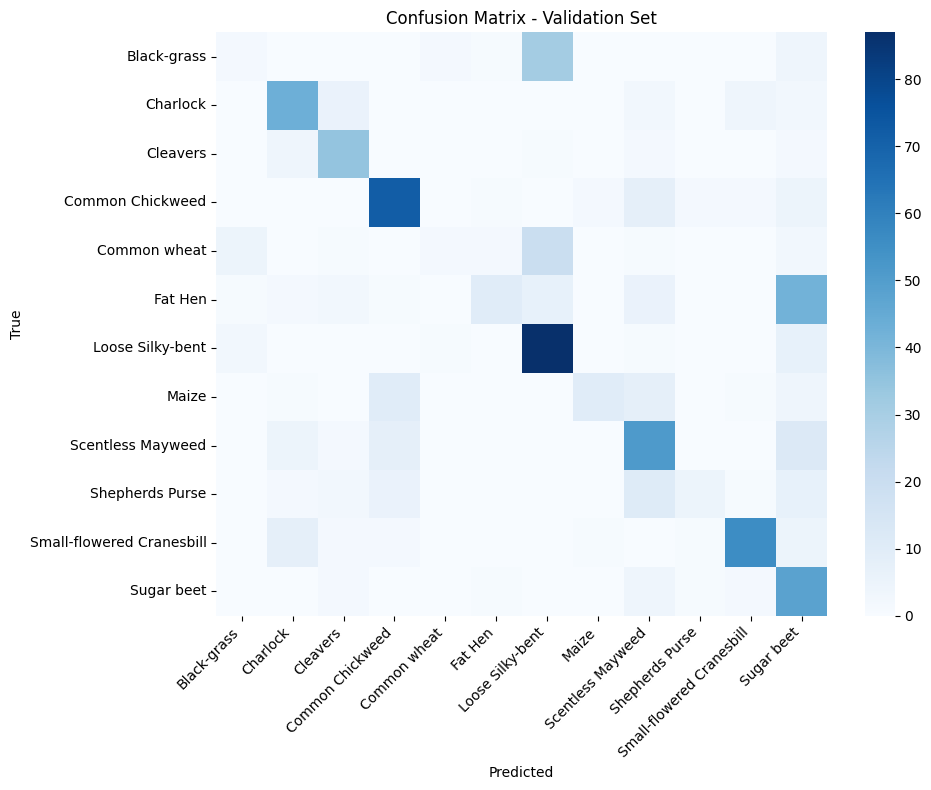

In [34]:
true_labels, pred_labels = evaluate_model(model, val_loader, device='cpu')

# Overall accuracy
overall_acc = (true_labels == pred_labels).mean()
print(f"Overall Validation Accuracy: {overall_acc:.2%}")

# Classification Report
print("\nClassification Report:")

class_names = train_dataset.dataset.classes if hasattr(train_dataset, 'dataset') else train_dataset.classes
print(classification_report(true_labels, pred_labels, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Validation Set")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
model.eval()
test_preds = []

with torch.no_grad():
    for inputs, _ in tqdm(test_loader, desc="Generating Test Predictions"):
        inputs = inputs.to("cpu")
        outputs = model(inputs)
        preds = outputs.argmax(1)
        test_preds.extend(preds.cpu().numpy())

filenames = [os.path.basename(path) for path, _ in test_dataset.samples]

class_names = train_dataset.dataset.classes if hasattr(train_dataset, 'dataset') else train_dataset.classes
predicted_species = [class_names[p] for p in test_preds]

submission_df = pd.DataFrame({
    'file': filenames,
    'species': predicted_species
})

submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

Generating Test Predictions: 100%|██████████| 100/100 [00:47<00:00,  2.09it/s]

Saved submission.csv successfully!


In [39]:
df= pd.read_csv("submission.csv")
df.head()

,file,species
0,0021e90e4.png,Small-flowered Cranesbill
1,003d61042.png,Sugar beet
2,007b3da8b.png,Sugar beet
3,0086a6340.png,Common Chickweed
4,00c47e980.png,Sugar beet


In [40]:
df['species'].value_counts()

,count
species,
Sugar beet,181
Loose Silky-bent,169
Small-flowered Cranesbill,107
Common Chickweed,83
Scentless Mayweed,69
Charlock,59
Cleavers,57
Maize,31
Black-grass,15


/tmp/ipykernel_4835/1546346835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='species', order=df['species'].value_counts().index, palette='viridis')


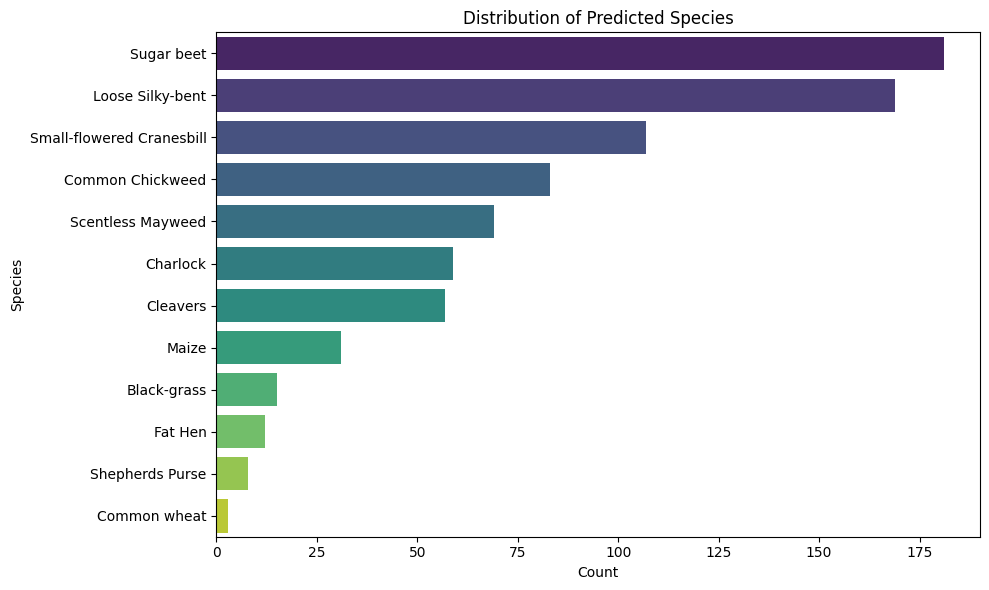

In [41]:

plt.figure(figsize=(10, 6))

sns.countplot(data=df, y='species', order=df['species'].value_counts().index, palette='viridis')

plt.title("Distribution of Predicted Species")
plt.xlabel("Count")
plt.ylabel("Species")
plt.tight_layout()
plt.show()